# A Closed Form Solution for Pricing Options: The Black-Scholes Model

## Load the Libs

In [1]:
# import Lib
import pandas as pd
import datetime as dt
import pytz
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as si

# import module
from datetime import datetime, timezone
from datetime import date, time
from math import trunc
from dateutil.parser import parse


## Black-Scholes Pricing for Calls and Puts

### The model function

#### A canonical / pedagogical implementation

In [2]:
def mb_black_scholes(
    spot_price,
    strike_price,
    time_to_maturity,
    risk_free_rate,
    volatility,
    option='call'
):
    """
    Canonical Black–Scholes implementation with explicit variable names.
    Compute the Black–Scholes price of a European option.

    Parameters
    ----------
    spot_price : float
        Current price of the underlying asset.
    strike_price : float
        Option strike price.
    time_to_maturity : float
        Time to expiration, expressed in years.
    risk_free_rate : float
        Continuously compounded risk-free interest rate.
    volatility : float
        Annualized volatility of the underlying asset.
    option : str, optional
        Option type: 'call' or 'put' (default is 'call').

    Returns
    -------
    float
        Theoretical Black–Scholes option price.

    Notes
    -----
    This implementation assumes:
    - European-style exercise
    - A non-dividend-paying underlying asset
    - Constant volatility and interest rates
    """
    # d1 and d2 are the standard Black–Scholes terms
    d1 = (
        np.log(spot_price / strike_price)
        + (risk_free_rate + 0.5 * volatility**2) * time_to_maturity
    ) / (volatility * np.sqrt(time_to_maturity))

    d2 = d1 - volatility * np.sqrt(time_to_maturity)

    if option == 'call':
        return (
            spot_price * si.norm.cdf(d1)
            - strike_price * np.exp(-risk_free_rate * time_to_maturity)
            * si.norm.cdf(d2)
        )

    if option == 'put':
        return (
            strike_price * np.exp(-risk_free_rate * time_to_maturity)
            * si.norm.cdf(-d2)
            - spot_price * si.norm.cdf(-d1)
        )

    raise ValueError("Option type must be 'call' or 'put'.")

#### A compact / symbolic implementation

In [3]:
def mb_bs_formula(S, K, T, r, v, option='call'):
    """
    Compact Black–Scholes closed-form formula using symbolic notation.
    Compute the Black–Scholes price of a European option.
    
    Parameters
    ----------
    S : float, spot price of the underlying asset
    K : float, strike price
    T : float, time to maturity (in years)
    r : float, risk-free interest rate
    v : float, volatility of the underlying asset
    option : str, 'call' or 'put'

    Returns
    -------
    float, Black–Scholes option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)

    if option == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)

    elif option == 'put':
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

    else:
        raise ValueError("Option type must be 'call' or 'put'.")

#### Pricing some calls and puts

In [4]:
call_price = mb_black_scholes(273, 250, 1, 0.035, 0.28, option = 'call')
put_price = mb_black_scholes(273, 250, 1, 0.035, 0.28, option = 'put')

print(f"Call option price: {call_price:.2f}")
print(f"Put option price:  {put_price:.2f}")

Call option price: 47.13
Put option price:  15.54


In [5]:
call_price = mb_bs_formula(273, 250, 1, 0.035, 0.28, option = 'call')
put_price = mb_bs_formula(273, 250, 1, 0.035, 0.28, option = 'put')

print(f"Call option price: {call_price:.2f}")
print(f"Put option price:  {put_price:.2f}")

Call option price: 47.13
Put option price:  15.54


### Put–Call Parity Check

In [6]:
# Put–call parity check
"""
Verify put-call parity for European options on a non-dividend-paying asset.

LHS: C - P
RHS: S - K * exp(-r * T)

Where:
- C is the call option price
- P is the put option price
- S is the spot price of the underlying asset
- K is the strike price
- r is the risk-free interest rate
- T is the time to maturity
"""

lhs = call_price - put_price
rhs = 273 - 250 * np.exp(-0.035 * 1)

print(f"LHS (Call - Put): {lhs:.4f}")
print(f"RHS (S - K * exp(-rT)): {rhs:.4f}")
print(f"Difference: {lhs - rhs:.6f}")

LHS (Call - Put): 31.5986
RHS (S - K * exp(-rT)): 31.5986
Difference: -0.000000


## European Model Prices Versus American Market Options Consistency Check

#### Read the files into dataframes

In [7]:
mb_src_prices = pd.read_csv("mb_tickerdf12302025 2025-12-30 17-24-53-423976.csv", index_col=0)
mb_src_options = pd.read_csv("mb_all_options_data12302025 2025-12-30 17-24-55-033746.csv", index_col=0)
mb_src_ir = pd.read_csv("mb_US_T_12292025 2025-12-30 17-06-29-282207.csv", index_col=0)

# Parsing the dates in the index and convert them to date only (without time or timezone info)
mb_src_prices.index = mb_src_prices.index.map(lambda x: parse(x).date())

In [8]:
# Prices Dataframe
mb_src_prices

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2020-12-31,130.520487,131.162969,128.223139,129.167389,99116600,0.0,0.0
2021-01-04,129.975370,130.062977,123.394829,125.974480,143301900,0.0,0.0
2021-01-05,125.468261,128.242606,125.020466,127.531975,97664900,0.0,0.0
2021-01-06,124.329352,127.570950,123.024922,123.239082,155088000,0.0,0.0
2021-01-07,124.952354,128.135547,124.465627,127.444389,109578200,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-23,270.839996,272.500000,269.559998,272.359985,29642000,0.0,0.0
2025-12-24,272.339996,275.429993,272.200012,273.809998,17910600,0.0,0.0
2025-12-26,274.160004,275.369995,272.859985,273.399994,21521800,0.0,0.0
2025-12-29,272.690002,274.359985,272.350006,273.760010,23715200,0.0,0.0


In [9]:
# Take a copy of the prices dataframe
mb_src_prices_HistVol = mb_src_prices.copy()

# Calculate daily returns
mb_src_prices_HistVol['Daily Return'] = mb_src_prices_HistVol['Close'].pct_change()

# Calculate the rolling standard deviation of daily returns (volatility)
# Assuming 252 trading days in a year
mb_src_prices_HistVol['Daily Volatility'] = mb_src_prices_HistVol['Daily Return'].rolling(window=252).std()

# Convert daily volatility to yearly volatility
mb_src_prices_HistVol['Yearly Volatility'] = mb_src_prices_HistVol['Daily Volatility'] * np.sqrt(252)

# Drop NaN values resulting from the rolling window
mb_src_prices_HistVol.dropna(inplace=True)

# Prices and Historical Volatilities Series
mb_src_prices_HistVol

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Daily Return,Daily Volatility,Yearly Volatility
2021-12-31,174.430829,175.547405,173.617881,173.921524,64062300,0.0,0.0,-0.003535,0.015813,0.251019
2022-01-03,174.176201,179.122444,174.058672,178.270309,104487900,0.0,0.0,0.025004,0.015797,0.250768
2022-01-04,178.877588,179.181217,175.439697,176.007782,99310400,0.0,0.0,-0.012692,0.015807,0.250931
2022-01-05,175.919596,176.468088,171.051713,171.325958,94537600,0.0,0.0,-0.026600,0.015751,0.250038
2022-01-06,169.151618,171.698203,168.113400,168.466003,96904000,0.0,0.0,-0.016693,0.015656,0.248526
...,...,...,...,...,...,...,...,...,...,...
2025-12-23,270.839996,272.500000,269.559998,272.359985,29642000,0.0,0.0,0.005130,0.020481,0.325119
2025-12-24,272.339996,275.429993,272.200012,273.809998,17910600,0.0,0.0,0.005324,0.020450,0.324638
2025-12-26,274.160004,275.369995,272.859985,273.399994,21521800,0.0,0.0,-0.001497,0.020450,0.324634
2025-12-29,272.690002,274.359985,272.350006,273.760010,23715200,0.0,0.0,0.001317,0.020438,0.324448


In [10]:
# Options Dataframe
mb_src_options

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,OptionType,expirationDate,time_to_expiration
0,AAPL260102C00120000,2025-12-29 14:52:51+00:00,120.0,153.88,151.60,154.95,0.000000,0.000000,1.0,1,3.335939,True,REGULAR,USD,Call,2026-01-02,3
1,AAPL260102C00135000,2025-12-08 14:31:30+00:00,135.0,144.95,136.55,139.95,0.000000,0.000000,NaN,2,2.843753,True,REGULAR,USD,Call,2026-01-02,3
2,AAPL260102C00145000,2025-11-19 16:06:45+00:00,145.0,126.05,126.55,130.00,0.000000,0.000000,NaN,6,2.621097,True,REGULAR,USD,Call,2026-01-02,3
3,AAPL260102C00150000,2025-12-29 20:59:30+00:00,150.0,123.83,121.60,124.95,0.000000,0.000000,2.0,12,2.492191,True,REGULAR,USD,Call,2026-01-02,3
4,AAPL260102C00155000,2025-12-29 20:59:30+00:00,155.0,118.90,116.55,120.00,0.000000,0.000000,4.0,3,2.369145,True,REGULAR,USD,Call,2026-01-02,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2317,AAPL280317P00330000,2025-12-26 19:28:14+00:00,330.0,65.85,66.55,67.40,0.000000,0.000000,2.0,9,0.174355,True,REGULAR,USD,Put,2028-03-17,808
2318,AAPL280317P00340000,2025-12-30 17:32:03+00:00,340.0,74.42,73.70,74.50,1.199997,1.638892,2.0,1,0.165444,True,REGULAR,USD,Put,2028-03-17,808
2319,AAPL280317P00350000,2025-12-30 17:34:24+00:00,350.0,81.91,80.45,82.70,-0.369995,-0.449678,2.0,201,0.161980,True,REGULAR,USD,Put,2028-03-17,808
2320,AAPL280317P00380000,2025-12-22 14:30:05+00:00,380.0,107.46,106.30,108.45,0.000000,0.000000,200.0,201,0.140023,True,REGULAR,USD,Put,2028-03-17,808


In [11]:
# IR Dataframe
mb_src_ir

,US_Treasury_Pillar,Yield
0,1M,3.69
1,3M,3.68
2,6M,3.59
3,1Y,3.48
4,2Y,3.45
5,3Y,3.51
6,5Y,3.67
7,7Y,3.88
8,10Y,4.12
9,20Y,4.75


In [12]:
"""
This code retrieves and displays information about a specific option based on its strike price and time to expiration from a DataFrame.

Parameters:
- strike_target (float): The target strike price of the option to look for.
- expiration_target (int): The target time to expiration of the option (in days).
Options with Strike = 250 and expiration time = 353 days tenor

The code filters the DataFrame to find the row that matches the specified strike price and time to expiration, 
then transposes the result for easier viewing.
"""

# Define target parameters
strike_target = 250          # Target strike price
expiration_target = 353      # Target time to expiration (in days)

# Retrieve the row corresponding to the specified strike price and expiration time
mb_row_target = mb_src_options.loc[
    (mb_src_options['strike'] == strike_target) & 
    (mb_src_options['time_to_expiration'] == expiration_target)
]

# Transpose the result for better readability
mb_row_target.transpose()


,1557,1642
contractSymbol,AAPL261218C00250000,AAPL261218P00250000
lastTradeDate,2025-12-30 20:54:40+00:00,2025-12-30 20:02:52+00:00
strike,250.0,250.0
lastPrice,45.95,14.7
bid,45.7,14.7
ask,46.1,14.9
change,-0.549999,0.05
percentChange,-1.182794,0.341298
volume,13.0,41.0
openInterest,9774,2951


#### Pricing Using American Options Implied Volatilities

In [13]:
call_price1 = mb_black_scholes(273, 250, 1, 0.035, 0.32, option = 'call')
put_price1 = mb_black_scholes(273, 250, 1, 0.035, 0.24, option = 'put')

print(f"The Black-Scholes price of the call option 1 is: {call_price1:.2f}")
print(f"The Black-Scholes price of the put option 1 is: {put_price1:.2f}")

The Black-Scholes price of the call option 1 is: 50.86
The Black-Scholes price of the put option 1 is: 11.91


#### Using Historical Volatilities

In [14]:
call_price2 = mb_black_scholes(273, 250, 1, 0.035, 0.32, option = 'call')
put_price2 = mb_black_scholes(273, 250, 1, 0.035, 0.32, option = 'put')

print(f"The Black-Scholes price of the call option 2 is: {call_price2:.2f}")
print(f"The Black-Scholes price of the put option 2 is: {put_price2:.2f}")

The Black-Scholes price of the call option 2 is: 50.86
The Black-Scholes price of the put option 2 is: 19.26


#### Pricing Using the Average of Call and Put American Implied Volatilities

In [15]:
call_price3 = mb_black_scholes(273, 250, 1, 0.035, 0.28, option = 'call')
put_price3 = mb_black_scholes(273, 250, 1, 0.035, 0.28, option = 'put')

print(f"The Black-Scholes price of the call option 3 is: {call_price3:.2f}")
print(f"The Black-Scholes price of the put option 3 is: {put_price3:.2f}")

The Black-Scholes price of the call option 3 is: 47.13
The Black-Scholes price of the put option 3 is: 15.54


#### Matching American Market Prices with European Model Prices Using Implied Volatility

In [16]:
call_price4 = mb_black_scholes(273, 250, 1, 0.035, 0.267, option = 'call')
put_price4 = mb_black_scholes(273, 250, 1, 0.035, 0.272, option = 'put')

print(f"The Black-Scholes price of the call option 3 is: {call_price4:.2f}")
print(f"The Black-Scholes price of the put option 3 is: {put_price4:.2f}")

The Black-Scholes price of the call option 3 is: 45.94
The Black-Scholes price of the put option 3 is: 14.80


## Simulations and Stress Testing

#### Spot Ladder

In [17]:
# SPOT LADDER

"""
This code calculates the call and put option prices for a range of spot prices using the Black-Scholes model.

Parameters:
- strike_price: The strike price of the option.
- time_to_maturity: The time remaining until the option expires (in years).
- risk_free_rate: The annualized risk-free interest rate used in the pricing model.
- volatility: The annualized volatility of the underlying asset.

The results are stored in a DataFrame for further analysis and visualization.
"""

# Define parameters
strike_price = 275                # Strike price of the option
time_to_maturity = 1              # Time to maturity (in years)
risk_free_rate = 0.035            # Risk-free interest rate (annualized)
volatility = 0.28                 # Volatility of the underlying asset (annualized)

# Define range for spot price
spot_price_range = np.arange(75, 500, 25)

# Calculate call and put prices for each spot price
call_prices = [mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call') for spot_price in spot_price_range]
put_prices = [mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put') for spot_price in spot_price_range]

# Create DataFrame
mb_df = pd.DataFrame({
    'Spot Price': spot_price_range,
    'Call Price': call_prices,
    'Put Price': put_prices
})

# Display DataFrame
mb_df

,Spot Price,Call Price,Put Price
0,75,0.000025,190.541515
1,100,0.002776,165.544265
2,125,0.055247,140.596737
3,150,0.422949,115.964439
4,175,1.800038,92.341528
5,200,5.218294,70.759783
6,225,11.639755,52.181245
7,250,21.588083,37.129572
8,275,35.054431,25.595920
9,300,51.631943,17.173433


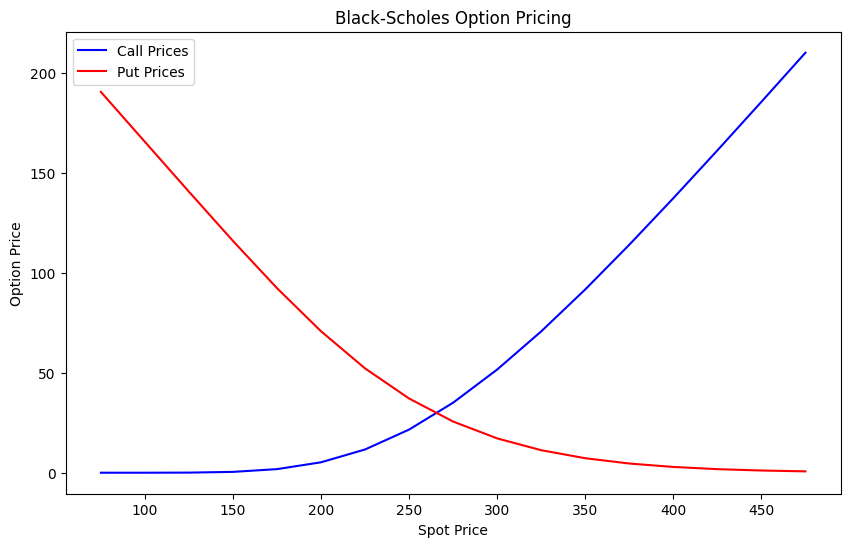

In [18]:
# Set plot size and title
plt.figure(figsize=(10, 6))
plt.title('Black-Scholes Option Pricing')

# Plot call and put prices
plt.plot(mb_df['Spot Price'], mb_df['Call Price'], label='Call Prices', color='blue')
plt.plot(mb_df['Spot Price'], mb_df['Put Price'], label='Put Prices', color='red')

# Set labels and legend
plt.xlabel('Spot Price')
plt.ylabel('Option Price')
plt.legend()

# Display plot
plt.show()

#### Spot and Vol Ladders

In [19]:
# Spot and Vol Ladders
"""
This code calculates call and put option prices for a range of spot prices and volatilities using the Black-Scholes model.

Parameters:
- strike_price: The strike price of the option.
- time_to_maturity: The time remaining until the option expires (in years).
- risk_free_rate: The annualized risk-free interest rate used in the pricing model.
- spot_price_range: A range of possible spot prices for the underlying asset.
- volatility_range: A range of volatility values for the underlying asset.

The results are compiled into a DataFrame that provides a comprehensive view of option prices under varying conditions.
"""

# Define parameters
strike_price = 275                # Strike price of the option
time_to_maturity = 1              # Time to maturity (in years)
risk_free_rate = 0.035            # Risk-free interest rate (annualized)

# Define range for spot price
spot_price_range = np.arange(75, 500, 25)

# Define range for volatility
volatility_range = np.arange(0.08, 0.53, 0.05)

# Calculate call and put prices for each spot price and volatility
vol_ladder = []
for volatility in volatility_range:
    call_prices = [mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call') for spot_price in spot_price_range]
    put_prices = [mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put') for spot_price in spot_price_range]
    
    vol_ladder.append(pd.DataFrame({
        'Volatility': [volatility] * len(spot_price_range),
        'Spot Price': spot_price_range,
        'Call Price': call_prices,
        'Put Price': put_prices
    }))

# Concatenate all dataframes
mb_vol_ladder_df = pd.concat(vol_ladder, ignore_index=True)

# Display the DataFrame
mb_vol_ladder_df

,Volatility,Spot Price,Call Price,Put Price
0,0.08,75,1.041563e-56,190.541489
1,0.08,100,1.492509e-34,165.541489
2,0.08,125,3.471565e-21,140.541489
3,0.08,150,1.011314e-12,115.541489
4,0.08,175,2.889225e-07,90.541490
...,...,...,...,...
148,0.48,375,1.300692e+02,20.610698
149,0.48,400,1.512595e+02,16.801030
150,0.48,425,1.731663e+02,13.707817
151,0.48,450,1.956559e+02,11.197400


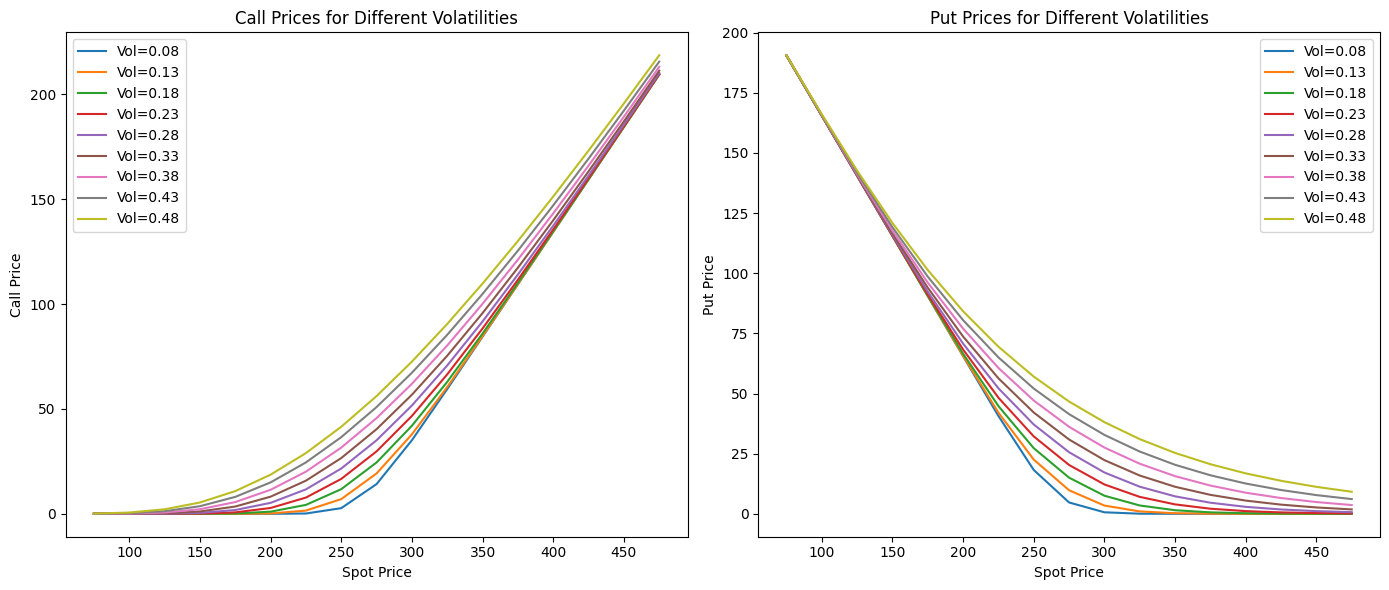

In [20]:
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for v in volatility_range:
    mb_df = mb_vol_ladder_df[mb_vol_ladder_df['Volatility'] == v]
    ax[0].plot(mb_df['Spot Price'], mb_df['Call Price'], label=f'Vol={v:.2f}')
    ax[1].plot(mb_df['Spot Price'], mb_df['Put Price'], label=f'Vol={v:.2f}')

ax[0].set_title('Call Prices for Different Volatilities')
ax[0].set_xlabel('Spot Price')
ax[0].set_ylabel('Call Price')
ax[0].legend()

ax[1].set_title('Put Prices for Different Volatilities')
ax[1].set_xlabel('Spot Price')
ax[1].set_ylabel('Put Price')
ax[1].legend()

plt.tight_layout()
plt.show()

## Decoding the Greeks

### Analytical approach, based on the closed-form solution of the Black-Scholes model

In [21]:
def mb_bs_delta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call'):
    """
    Calculate the Delta of an option using the Black-Scholes model.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).
    option (str): Type of option ('call' or 'put'). Default is 'call'.

    Returns:
    float: The Delta of the option.
    """
    d1 = (np.log(spot_price / strike_price) + (risk_free_rate + 0.5 * volatility ** 2) * time_to_maturity) / (volatility * np.sqrt(time_to_maturity))
    if option == 'call':
        delta = si.norm.cdf(d1, 0.0, 1.0)
    elif option == 'put':
        delta = si.norm.cdf(d1, 0.0, 1.0) - 1
    return delta

In [22]:
def mb_bs_gamma(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    """
    Calculate the Gamma of an option using the Black-Scholes model.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).

    Returns:
    float: The Gamma of the option.
    """
    d1 = (np.log(spot_price / strike_price) + (risk_free_rate + 0.5 * volatility ** 2) * time_to_maturity) / (volatility * np.sqrt(time_to_maturity))
    gamma = si.norm.pdf(d1, 0.0, 1.0) / (spot_price * volatility * np.sqrt(time_to_maturity))
    return gamma

In [23]:
def mb_bs_vega(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    """
    Calculate the Vega of an option using the Black-Scholes model.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).

    Returns:
    float: The Vega of the option.
    """
    d1 = (np.log(spot_price / strike_price) + (risk_free_rate + 0.5 * volatility ** 2) * time_to_maturity) / (volatility * np.sqrt(time_to_maturity))
    vega = spot_price * si.norm.pdf(d1, 0.0, 1.0) * np.sqrt(time_to_maturity)
    return vega

In [24]:
def mb_bs_theta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call'):
    """
    Calculate the Theta of an option using the Black-Scholes model.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).
    option (str): Type of option ('call' or 'put'). Default is 'call'.

    Returns:
    float: The Theta of the option.
    """
    d1 = (np.log(spot_price / strike_price) + (risk_free_rate + 0.5 * volatility ** 2) * time_to_maturity) / (volatility * np.sqrt(time_to_maturity))
    d2 = d1 - volatility * np.sqrt(time_to_maturity)
    if option == 'call':
        theta = -(spot_price * si.norm.pdf(d1, 0.0, 1.0) * volatility / (2 * np.sqrt(time_to_maturity))) - risk_free_rate * strike_price * np.exp(-risk_free_rate * time_to_maturity) * si.norm.cdf(d2, 0.0, 1.0)
    elif option == 'put':
        theta = -(spot_price * si.norm.pdf(d1, 0.0, 1.0) * volatility / (2 * np.sqrt(time_to_maturity))) + risk_free_rate * strike_price * np.exp(-risk_free_rate * time_to_maturity) * si.norm.cdf(-d2, 0.0, 1.0)
    return theta

In [25]:
def mb_bs_rho(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call'):
    """
    Calculate the Rho of an option using the Black-Scholes model.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).
    option (str): Type of option ('call' or 'put'). Default is 'call'.

    Returns:
    float: The Rho of the option.
    """
    d2 = (np.log(spot_price / strike_price) + (risk_free_rate - 0.5 * volatility ** 2) * time_to_maturity) / (volatility * np.sqrt(time_to_maturity))
    if option == 'call':
        rho = strike_price * time_to_maturity * np.exp(-risk_free_rate * time_to_maturity) * si.norm.cdf(d2, 0.0, 1.0)
    elif option == 'put':
        rho = -strike_price * time_to_maturity * np.exp(-risk_free_rate * time_to_maturity) * si.norm.cdf(-d2, 0.0, 1.0)
    return rho

### Numerical approach, based on the concept of finite differences

In [26]:
def mb_numerical_delta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call'):
    """
    Calculate the Delta of an option using the numerical approach.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).
    option (str): Type of option ('call' or 'put'). Default is 'call'.

    Returns:
    float: The Delta of the option.
    """
    dS = 0.01 * spot_price
    option_plus = mb_black_scholes(spot_price + dS, strike_price, time_to_maturity, risk_free_rate, volatility, option)
    option_minus = mb_black_scholes(spot_price - dS, strike_price, time_to_maturity, risk_free_rate, volatility, option)
    delta = (option_plus - option_minus) / (2 * dS)
    return delta

In [27]:
def mb_numerical_gamma(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    """
    Calculate the Gamma of an option using the numerical approach.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).

    Returns:
    float: The Gamma of the option.
    """
    dS = 0.01 * spot_price
    delta_plus = mb_numerical_delta(spot_price + dS, strike_price, time_to_maturity, risk_free_rate, volatility)
    delta_minus = mb_numerical_delta(spot_price - dS, strike_price, time_to_maturity, risk_free_rate, volatility)
    gamma = (delta_plus - delta_minus) / (2 * dS)
    return gamma

In [28]:
def mb_numerical_vega(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility):
    """
    Calculate the Vega of an option using the numerical approach.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).

    Returns:
    float: The Vega of the option.
    """
    dv = 0.01 * volatility
    option_plus = mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility + dv)
    option_minus = mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility - dv)
    vega = (option_plus - option_minus) / (2 * dv)
    return vega

In [29]:
def mb_numerical_theta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call'):
    """
    Numerical Theta using a backward difference in time (time decay).
    Returns dV/dT (per year), consistent with analytical Theta.
    """
    dT = 1e-4  # small absolute step in years (e.g., ~0.0365 days)
    if time_to_maturity <= dT:
        raise ValueError("time_to_maturity must be larger than dT for numerical theta.")
    
    price_now  = mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option)
    price_less = mb_black_scholes(spot_price, strike_price, time_to_maturity - dT, risk_free_rate, volatility, option)

    theta = (price_less - price_now) / dT  # negative for most options
    return theta

In [30]:
def mb_numerical_rho(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call'):
    """
    Calculate the Rho of an option using the numerical approach.

    Parameters:
    spot_price (float): Current price of the underlying asset.
    strike_price (float): Strike price of the option.
    time_to_maturity (float): Time to maturity (in years).
    risk_free_rate (float): Risk-free interest rate (annualized).
    volatility (float): Volatility of the underlying asset (annualized).
    option (str): Type of option ('call' or 'put'). Default is 'call'.

    Returns:
    float: The Rho of the option.
    """
    dr = 0.01 * risk_free_rate
    option_plus = mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate + dr, volatility, option)
    option_minus = mb_black_scholes(spot_price, strike_price, time_to_maturity, risk_free_rate - dr, volatility, option)
    rho = (option_plus - option_minus) / (2 * dr)
    return rho

#### Greeks check (Analytical vs Numerical)

In [31]:
# =============================================================================
# Greeks check (Analytical vs Numerical) using:
# S = 275, K = 275, T = 1 year, r = 3.5%, vol = 28%
# =============================================================================

spot_price = 275
strike_price = 275
time_to_maturity = 1
risk_free_rate = 0.035
volatility = 0.28

# -----------------------------
# Delta (Call / Put)
# -----------------------------
call_a_delta = mb_bs_delta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call')
call_n_delta = mb_numerical_delta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call')

put_a_delta  = mb_bs_delta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put')
put_n_delta  = mb_numerical_delta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put')

# -----------------------------
# Gamma (same for Call / Put)
# -----------------------------
a_gamma = mb_bs_gamma(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility)
n_gamma = mb_numerical_gamma(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility)

# -----------------------------
# Vega (same for Call / Put)
# -----------------------------
a_vega = mb_bs_vega(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility)
n_vega = mb_numerical_vega(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility)

# -----------------------------
# Theta (Call / Put)
# Note: your analytical theta function returns annualized theta (per year).
# If you want per-day theta, divide by 365.
# -----------------------------
call_a_theta = mb_bs_theta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call')
call_n_theta = mb_numerical_theta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call')

put_a_theta  = mb_bs_theta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put')
put_n_theta  = mb_numerical_theta(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put')

# -----------------------------
# Rho (Call / Put)
# Note: Rho is typically quoted per 1% change in rates.
# If your functions return per 1.00 change in r, divide by 100 for per-1% convention.
# -----------------------------
call_a_rho = mb_bs_rho(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call')
call_n_rho = mb_numerical_rho(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='call')

put_a_rho  = mb_bs_rho(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put')
put_n_rho  = mb_numerical_rho(spot_price, strike_price, time_to_maturity, risk_free_rate, volatility, option='put')

# =============================================================================
# Collect results into a DataFrame (Analytical vs Numerical vs Difference)
# =============================================================================

data = [
    # Delta
    ["Delta", "Call", call_a_delta, call_n_delta, call_a_delta - call_n_delta],
    ["Delta", "Put",  put_a_delta,  put_n_delta,  put_a_delta  - put_n_delta],

    # Gamma
    ["Gamma", "Both", a_gamma, n_gamma, a_gamma - n_gamma],

    # Vega
    ["Vega", "Both", a_vega, n_vega, a_vega - n_vega],

    # Theta
    ["Theta", "Call", call_a_theta, call_n_theta, call_a_theta - call_n_theta],
    ["Theta", "Put",  put_a_theta,  put_n_theta,  put_a_theta  - put_n_theta],

    # Rho
    ["Rho", "Call", call_a_rho, call_n_rho, call_a_rho - call_n_rho],
    ["Rho", "Put",  put_a_rho,  put_n_rho,  put_a_rho  - put_n_rho],
]

df_greeks_check = pd.DataFrame(
    data,
    columns=["Greek", "Option Type", "Analytical Value", "Numerical Value", "Difference (A - N)"]
)

df_greeks_check

,Greek,Option Type,Analytical Value,Numerical Value,Difference (A - N)
0,Delta,Call,0.604495,0.604451,0.000045
1,Delta,Put,-0.395505,-0.395549,0.000045
2,Gamma,Both,0.005002,0.005001,0.000001
3,Vega,Both,105.923810,105.923693,0.000117
4,Theta,Call,-19.420695,-19.421102,0.000406
5,Theta,Put,-10.126743,-10.127133,0.000390
6,Rho,Call,131.181768,131.181756,0.000012
7,Rho,Put,-134.359721,-134.359739,0.000018
